# Размечаем датасет


In [1]:
import json
import os
import sys
import types
from collections import defaultdict
from datetime import datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

from dotenv import load_dotenv

import cattr
import httpx._types as httpx_types

if not hasattr(httpx_types, "VerifyTypes"):
    httpx_types.VerifyTypes = bool | str | Path

if "pkg_resources" not in sys.modules:
    pkg_resources = types.ModuleType("pkg_resources")

    class _Distribution:
        def __init__(self, package_name: str):
            self.version = version(package_name)

    pkg_resources.get_distribution = _Distribution
    sys.modules["pkg_resources"] = pkg_resources

if not hasattr(cattr.converters.BaseConverter, "_unstructure_enum"):
    def _unstructure_enum(self, obj):
        return obj.value

    cattr.converters.BaseConverter._unstructure_enum = _unstructure_enum

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
import toloka.client as toloka
from datasets import load_dataset


In [2]:
load_dotenv()

TOKEN = os.getenv("TOLOKA_TOKEN")
if not TOKEN:
    raise ValueError("Не найден TOLOKA_TOKEN")

TOLOKA_API_URL = "https://tasks.yandex.ru"
HF_DATASET_REPO_ID = "vsevolod-nv/aiconf-butterfly-detection-all"
HF_DATASET_SPLIT = "train"
toloka_client = toloka.TolokaClient(TOKEN, url=TOLOKA_API_URL)

current_dir = Path.cwd()
tasks_dir = current_dir if (current_dir / "data").exists() else current_dir / "tasks"
data_dir = tasks_dir / "data"


In [3]:
requester = toloka_client.get_requester()
print("public name:", getattr(requester, "public_name", None))
print("balance:", getattr(requester, "balance", None))


public name: {'EN': 'eraserhead@aiconf-2026'}
balance: 1491.4000


## Готовим сбалансированный датасет

Берем единый датасет из Hugging Face, где уже есть `taxon`, `photo_id`, `photo_url`, `hard`.
Позитивы собираем из `butterfly`, негативный класс равномерно из `bee`, `beetle`, `flower`, `shrub`.


In [4]:
source_df = load_dataset(HF_DATASET_REPO_ID, split=HF_DATASET_SPLIT).to_pandas()
prepared_dataset_path = tasks_dir / "data" / "mine_larger_goldenset_balanced.tsv"

butterflies = source_df[source_df["taxon"] == "butterfly"].to_dict("records")
bees = source_df[source_df["taxon"] == "bee"].to_dict("records")
beetles = source_df[source_df["taxon"] == "beetle"].to_dict("records")
flowers = source_df[source_df["taxon"] == "flower"].to_dict("records")
shrubs = source_df[source_df["taxon"] == "shrub"].to_dict("records")

positive_rows = []
for item in butterflies[:150]:
    positive_rows.append(
        {
            "image": item["photo_url"],
            "photo_id": str(item["photo_id"]),
            "taxon": "butterfly",
            "hard": str(item.get("hard", False)),
            "is_positive": True,
        }
    )

negative_rows = []
for source_name, source_items in [
    ("bee", bees[:38]),
    ("beetle", beetles[:38]),
    ("flower", flowers[:37]),
    ("shrub", shrubs[:37]),
]:
    for item in source_items:
        negative_rows.append(
            {
                "image": item["photo_url"],
                "photo_id": str(item["photo_id"]),
                "taxon": source_name,
                "hard": str(item.get("hard", False)),
                "is_positive": False,
            }
        )

prepared_df = pd.DataFrame(positive_rows + negative_rows)
prepared_df = prepared_df.sample(frac=1, random_state=42).reset_index(drop=True)
prepared_df.to_csv(prepared_dataset_path, sep="\t", index=False)

print("prepared rows:", len(prepared_df))
print(prepared_df["is_positive"].value_counts())
prepared_df.head()


prepared rows: 300
is_positive
False    150
True     150
Name: count, dtype: int64


,image,photo_id,taxon,hard,is_positive
0,https://inaturalist-open-data.s3.amazonaws.com...,624927546,beetle,False,False
1,https://inaturalist-open-data.s3.amazonaws.com...,605072725,shrub,False,False
2,https://inaturalist-open-data.s3.amazonaws.com...,624962628,bee,False,False
3,https://inaturalist-open-data.s3.amazonaws.com...,624793942,butterfly,False,True
4,https://inaturalist-open-data.s3.amazonaws.com...,624958793,flower,True,False


## Создаем bbox pool

Используем уже существующий bbox-проект.
В пул допускаем только исполнителей с `bbox skill >= 60`.


In [5]:
bbox_project_id = "9642"
bbox_skill_id = "16287"

bbox_pool = toloka.pool.Pool(
    project_id=bbox_project_id,
    private_name=f"mine_larger_goldenset_bbox_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    may_contain_adult_content=False,
    reward_per_assignment=0.25,
    assignment_max_duration_seconds=20 * 60,
    will_expire=datetime.now(timezone.utc) + timedelta(days=30),
    auto_accept_solutions=False,
    defaults=toloka.pool.Pool.Defaults(
        default_overlap_for_new_task_suites=1,
    ),
    filter=(
        (toloka.filter.ClientType == "BROWSER")
    ) & (
        toloka.filter.Languages.in_("RU")
    ) & (
        toloka.filter.Skill(bbox_skill_id) >= 60
    ) & toloka.filter.FilterOr([
        toloka.filter.RegionByPhone.in_(225),
        toloka.filter.RegionByIp.in_(225),
    ]),
)

bbox_pool.set_mixer_config(
    real_tasks_count=10,
    golden_tasks_count=0,
    training_tasks_count=0,
    min_real_tasks_count=10,
    force_last_assignment=True,
    mix_tasks_in_creation_order=False,
    shuffle_tasks_in_task_suite=False,
)

bbox_pool = toloka_client.create_pool(bbox_pool)
print("bbox_pool_id:", bbox_pool.id)


RetryError: HTTPSConnectionPool(host='tasks.yandex.ru', port=443): Max retries exceeded with url: /api/v1/pools (Caused by ResponseError('too many 500 error responses'))

In [ ]:
bbox_tasks = []

for row in prepared_df.itertuples(index=False):
    bbox_tasks.append(
        toloka.Task(
            pool_id=bbox_pool.id,
            input_values={
                "image": row.image,
                "taxon": str(row.taxon) if pd.notna(row.taxon) else "",
                "photo_id": str(row.photo_id) if pd.notna(row.photo_id) else "",
                "hard": str(row.hard) if pd.notna(row.hard) else "",
            },
        )
    )

bbox_upload_result = toloka_client.create_tasks(bbox_tasks, allow_defaults=True)
print("bbox tasks uploaded:", len(bbox_upload_result.items or {}))
print("bbox validation errors:", len(bbox_upload_result.validation_errors or {}))


100%|██████████| 100/100 [00:34<00:00,  2.87it/s]


bbox tasks uploaded: 300
bbox validation errors: 0


In [ ]:
fresh_bbox_pool = toloka_client.get_pool(bbox_pool.id)
print("bbox_pool_status:", getattr(fresh_bbox_pool, "status", None))
print("bbox_pool_last_close_reason:", getattr(fresh_bbox_pool, "last_close_reason", None))


bbox_pool_status: Status.CLOSED
bbox_pool_last_close_reason: None


## Создаем validation pool

Этот блок запускаем после того, как bbox pool разметился.
Если нужно переиспользовать уже существующий bbox pool, просто впишите его id в следующую ячейку.


In [ ]:
bbox_pool_id = "6124419"

if bbox_pool_id:
    bbox_pool = toloka_client.get_pool(bbox_pool_id)

print("using bbox_pool:", bbox_pool.id)


using bbox_pool: 6124419


In [ ]:
review_project_id = "9620"
review_project_skill_id = "16286"

validation_pool = toloka.pool.Pool(
    project_id=review_project_id,
    private_name=f"mine_larger_goldenset_validation_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    may_contain_adult_content=False,
    reward_per_assignment=0.5,
    assignment_max_duration_seconds=10 * 60,
    will_expire=datetime.now(timezone.utc) + timedelta(days=30),
    auto_accept_solutions=True,
    defaults=toloka.pool.Pool.Defaults(
        default_overlap_for_new_task_suites=3,
    ),
    mixer_config=toloka.pool.Pool.MixerConfig(
        real_tasks_count=10,
        golden_tasks_count=0,
        training_tasks_count=0,
        min_real_tasks_count=10,
        force_last_assignment=True,
        mix_tasks_in_creation_order=False,
        shuffle_tasks_in_task_suite=False,
    ),
    filter=(
        (toloka.filter.ClientType == "BROWSER")
    ) & (
        toloka.filter.Languages.in_("RU")
    ) & (
        toloka.filter.Skill(review_project_skill_id) >= 100
    ) & toloka.filter.FilterOr([
        toloka.filter.RegionByPhone.in_(225),
        toloka.filter.RegionByIp.in_(225),
    ]),
)

validation_pool = toloka_client.create_pool(validation_pool)
print("validation_pool_id:", validation_pool.id)


validation_pool_id: 6124771


In [ ]:
bbox_assignments = list(toloka_client.get_assignments(pool_id=bbox_pool.id))
print("bbox assignments:", len(bbox_assignments))

validation_tasks = []
validation_task_mapping = []

for assignment in bbox_assignments:
    tasks = assignment.tasks or []
    solutions = assignment.solutions or []

    for task_index, (task, solution) in enumerate(zip(tasks, solutions)):
        input_values = task.input_values or {}
        output_values = solution.output_values or {}

        guides = output_values.get("result") or []
        if isinstance(guides, str):
            guides = json.loads(guides)
        if isinstance(guides, dict):
            guides = [guides]

        validation_input_values = {
            "image": input_values["image"],
            "guides": guides,
        }

        for field_name in ("hard", "taxon", "photo_id"):
            field_value = input_values.get(field_name)
            if field_value not in (None, ""):
                validation_input_values[field_name] = str(field_value)

        validation_tasks.append(
            toloka.Task(
                pool_id=validation_pool.id,
                input_values=validation_input_values,
                unavailable_for=[assignment.user_id] if assignment.user_id else None,
            )
        )

        validation_task_mapping.append(
            {
                "bbox_assignment_id": assignment.id,
                "bbox_worker_id": assignment.user_id,
                "bbox_pool_id": bbox_pool.id,
                "bbox_task_index": task_index,
                "image": validation_input_values["image"],
                "photo_id": validation_input_values.get("photo_id"),
            }
        )

print("validation tasks prepared:", len(validation_tasks))
print("unique images:", len({row["image"] for row in validation_task_mapping}))


bbox assignments: 44
validation tasks prepared: 300
unique images: 300


In [ ]:
validation_upload_result = toloka_client.create_tasks(validation_tasks, allow_defaults=True)
print("validation tasks uploaded:", len(validation_upload_result.items or {}))
print("validation errors:", len(validation_upload_result.validation_errors or {}))

uploaded_validation_tasks = list((validation_upload_result.items or {}).values())
for uploaded_task, mapping in zip(uploaded_validation_tasks, validation_task_mapping):
    mapping["validation_task_id"] = uploaded_task.id
    mapping["validation_pool_id"] = validation_pool.id

validation_mapping_path = tasks_dir / f"mine_larger_goldenset_mapping_{validation_pool.id}.json"
with validation_mapping_path.open("w", encoding="utf-8") as file:
    json.dump(validation_task_mapping, file, ensure_ascii=False, indent=2)

print("mapping saved:", validation_mapping_path)


100%|██████████| 100/100 [00:30<00:00,  3.24it/s]


validation tasks uploaded: 300
validation errors: 0
mapping saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/mine_larger_goldenset_mapping_6124771.json


## Проверяем validation pool и сохраняем валидные данные


In [ ]:
validation_pool_id = "6124771"
validation_mapping_path = "/Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/mine_larger_goldenset_mapping_6124771.json"

if not validation_pool_id:
    validation_pool_id = validation_pool.id

if validation_mapping_path is None:
    validation_mapping_path = tasks_dir / f"mine_larger_goldenset_mapping_{validation_pool_id}.json"
else:
    validation_mapping_path = Path(validation_mapping_path)

with validation_mapping_path.open(encoding="utf-8") as file:
    validation_task_mapping = json.load(file)

validation_assignments = list(toloka_client.get_assignments(pool_id=validation_pool_id))
print("validation assignments:", len(validation_assignments))
print("mapping rows:", len(validation_task_mapping))


validation assignments: 92
mapping rows: 300


In [ ]:
validation_task_to_bbox = {row["validation_task_id"]: row for row in validation_task_mapping}
validation_votes = defaultdict(list)
validation_task_inputs = {}

for assignment in validation_assignments:
    tasks = assignment.tasks or []
    solutions = assignment.solutions or []

    for task, solution in zip(tasks, solutions):
        validation_task_id = getattr(task, "origin_task_id", None) or getattr(task, "id", None)
        if not validation_task_id:
            continue

        validation_task_id = str(validation_task_id)
        if validation_task_id not in validation_task_to_bbox:
            continue

        if validation_task_id not in validation_task_inputs:
            validation_task_inputs[validation_task_id] = task.input_values or {}

        output_values = solution.output_values or {}
        verdict = output_values.get("result")
        if not verdict:
            continue

        validation_votes[validation_task_id].append(
            {
                "assignment_id": assignment.id,
                "reviewer_id": assignment.user_id,
                "verdict": verdict,
            }
        )

print("validation tasks with votes:", len(validation_votes))


validation tasks with votes: 300


In [ ]:
validated_rows = []

for validation_task_id, mapping_row in validation_task_to_bbox.items():
    votes = validation_votes.get(validation_task_id, [])
    verdicts = [vote["verdict"] for vote in votes]

    input_values = validation_task_inputs.get(validation_task_id, {})
    guides = input_values.get("guides") or []
    has_guides = len(guides) > 0

    is_all_good = len(verdicts) == 3 and set(verdicts) == {"good"}
    is_all_abscence_and_empty = len(verdicts) == 3 and set(verdicts) == {"abscence"} and not has_guides
    is_valid = is_all_good or is_all_abscence_and_empty

    validated_rows.append(
        {
            "validation_task_id": validation_task_id,
            "bbox_assignment_id": mapping_row["bbox_assignment_id"],
            "bbox_worker_id": mapping_row["bbox_worker_id"],
            "image": mapping_row["image"],
            "photo_id": mapping_row.get("photo_id"),
            "guides": guides,
            "has_bbox": has_guides,
            "votes_count": len(votes),
            "all_verdicts": verdicts,
            "is_valid": is_valid,
        }
    )

validated_df = pd.DataFrame(validated_rows)
print("all tasks:", len(validated_df))
print("valid tasks:", int(validated_df["is_valid"].sum()))
validated_df.head()


all tasks: 300
valid tasks: 154


,validation_task_id,bbox_assignment_id,bbox_worker_id,image,photo_id,guides,has_bbox,votes_count,all_verdicts,is_valid
0,00005d74e3--69e4f2f65aa9bb08b1a94319,00005d7383--69e4d71e548cec2176c26b99,3032f9fcf41b8d2886736d4e7b14edae,https://inaturalist-open-data.s3.amazonaws.com...,624962628,"[{'shape': 'rectangle', 'left': 0.455729962916...",True,3,"[good, abscence, abscence]",False
1,00005d74e3--69e4f2f65aa9bb08b1a94328,00005d7383--69e4d71e548cec2176c26b99,3032f9fcf41b8d2886736d4e7b14edae,https://inaturalist-open-data.s3.amazonaws.com...,624491511,"[{'shape': 'rectangle', 'left': 0.055211172029...",True,3,"[good, good, bad]",False
2,00005d74e3--69e4f2f65aa9bb08b1a94332,00005d7383--69e4d71e548cec2176c26b99,3032f9fcf41b8d2886736d4e7b14edae,https://inaturalist-open-data.s3.amazonaws.com...,624845123,"[{'shape': 'rectangle', 'left': 0.123574567864...",True,3,"[good, abscence, abscence]",False
3,00005d74e3--69e4f2f65aa9bb08b1a94339,00005d7383--69e4d71e548cec2176c26b99,3032f9fcf41b8d2886736d4e7b14edae,https://inaturalist-open-data.s3.amazonaws.com...,624963323,[],False,3,"[good, abscence, abscence]",False
4,00005d74e3--69e4f2f65aa9bb08b1a9433f,00005d7383--69e4d71e548cec2176c26b99,3032f9fcf41b8d2886736d4e7b14edae,https://inaturalist-open-data.s3.amazonaws.com...,624915357,[],False,3,"[good, abscence, abscence]",False


In [ ]:
valid_goldenset_df = validated_df[validated_df["is_valid"]].copy().reset_index(drop=True)
valid_goldenset_df["is_positive"] = valid_goldenset_df["has_bbox"]
valid_goldenset_df["is_negative"] = ~valid_goldenset_df["has_bbox"]

valid_json_path = tasks_dir / f"mine_larger_goldenset_valid_{validation_pool_id}.json"
valid_tsv_path = tasks_dir / f"mine_larger_goldenset_valid_{validation_pool_id}.tsv"
plot_path = tasks_dir / f"mine_larger_goldenset_valid_distribution_{validation_pool_id}.png"

valid_goldenset_df.to_json(valid_json_path, orient="records", force_ascii=False, indent=2)
valid_goldenset_df.to_csv(valid_tsv_path, sep="	", index=False)

print("saved:", valid_json_path)
print("saved:", valid_tsv_path)
print(valid_goldenset_df[["is_positive", "is_negative"]].sum())


saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/mine_larger_goldenset_valid_6124771.json
saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/mine_larger_goldenset_valid_6124771.tsv
is_positive    122
is_negative     32
dtype: int64


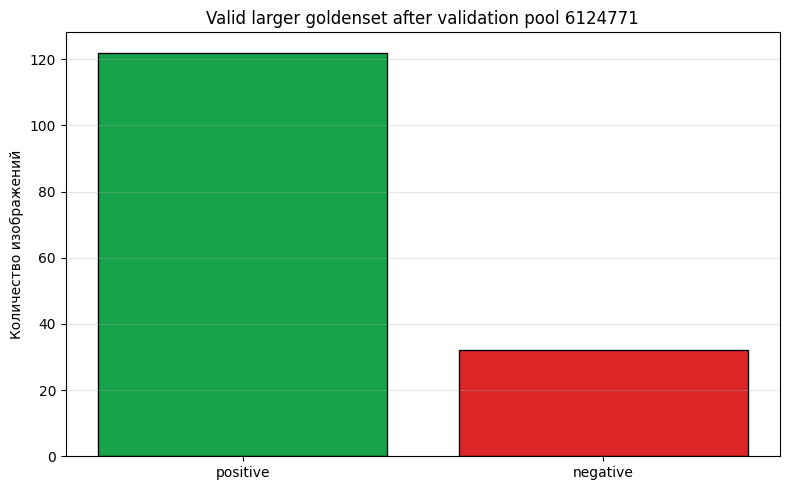

saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/mine_larger_goldenset_valid_distribution_6124771.png


In [ ]:
label_counts = pd.Series({
    "positive": int(valid_goldenset_df["is_positive"].sum()),
    "negative": int(valid_goldenset_df["is_negative"].sum()),
})

plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values, color=["#16a34a", "#dc2626"], edgecolor="black")
plt.title(f"Valid larger goldenset after validation pool {validation_pool_id}")
plt.ylabel("Количество изображений")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", plot_path)
